<a href="https://colab.research.google.com/github/lazybear-0425/EWC_Observation/blob/main/2025-03-26_00_23_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 - Life Lone Learning
 - Elastic Weight Consolidation (EWC)
    - [教學](https://www.kaggle.com/code/hughiephan/elastic-weight-consolidation-on-minst)
    - [Paper](https://arxiv.org/pdf/1612.00796)
    - 公式 $\mathcal{L}(\theta) = \mathcal{L}_B(\theta) + \frac\lambda2\sum^n_{i=1}F_i(\theta_i - \theta^*_{A,i})^2$
        - B是指目前任務，A是指前一個任務
 - [教學2](https://github.com/ContinualAI/colab/blob/master/notebooks/intro_to_continual_learning.ipynb)

In [1]:
import torch
from torch import nn
from torchvision.transforms import Compose, ToTensor, Normalize, RandomRotation, Lambda
import numpy as np
from torchvision.datasets import MNIST as FashionMNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.nn import CrossEntropyLoss
from torch.optim import Adam, SGD
from torch.nn.functional import cross_entropy

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
import random

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True  # 確保 CuDNN 使用確定性算法
torch.backends.cudnn.benchmark = False  # 禁止自適應選擇最佳內核，確保結果可重現

In [4]:
batch_size = 256
epochs = 10
task = 2

 - [ToTensor](https://pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html)

In [5]:
def trans_compose(i=0):
    return Compose([
        # lambda x : np.rot90(x, i, axes=[0, 1]).copy(), # 使連續
        # lambda x: np.expand_dims(x, axis=-1),  # 因為ToTensor要PIL or ndarray(H x W x C)，之後轉成Tensor(C x H x W)
        ToTensor(),
        # Lambda(lambda x : x / 255.),
        RandomRotation((90 * i, 90 * i)),
        Normalize(mean=[0.0], std=[1])
    ])

In [6]:
# preprocessing
# train_task_1 = FashionMNIST('data', train=True, transform=trans_compose(0), download=True)
# train_task_2 = FashionMNIST('data', train=True, transform=trans_compose(1), download=True)

test_task_1 = FashionMNIST('data', train=False, transform=trans_compose(0), download=True)
test_task_2 = FashionMNIST('data', train=False, transform=trans_compose(1), download=True)

task_1_loader = DataLoader(test_task_1, batch_size=batch_size)
task_2_loader = DataLoader(test_task_2, batch_size=batch_size)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 474kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.73MB/s]


In [7]:
class Module(nn.Module):
    def __init__(self):
        super(Module, self).__init__()
        # self.classifier = nn.Sequential(
        #     nn.Conv2d(1, 10, kernel_size=5),
        #     nn.MaxPool2d(2),
        #     nn.ReLU(),
        #     nn.Conv2d(10, 20, kernel_size=5),
        #     nn.Dropout2d(),
        #     nn.MaxPool2d(2),
        #     nn.ReLU(),
        # )
        # self.dense = nn.Sequential(
        #     nn.Linear(320, 50),
        #     nn.ReLU(),
        #     nn.Dropout(),
        #     nn.Linear(50, 10)
        # )
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(10)
        )
    def forward(self, X):
        # return self.dense(self.classifier(X).view(-1, 320))
        return self.net(X)

In [8]:
def evaluate(model, dataloader, num_data, num_task=-1):
    if num_task < 0: raise ValueError("Task Number is Missing")

    test_acc = 0
    test_loss = 0
    with torch.no_grad():
        model.eval()
        for data in dataloader:
            img, label = data
            img, label = img.to(device), label.to(device).long()
            output = model(img)
            test_loss += cross_entropy(output, label)
            test_acc += (output.argmax(1) == label).sum()
    print('\033[33m' +
          f'Task {num_task} Acc: {test_acc / num_data: .4f}, Loss: {test_loss / num_data: .4f}' +
          '\033[0m')

In [9]:
def training_Setting(model):
    optimizer = Adam(model.parameters())
    loss = CrossEntropyLoss()
    return optimizer, loss

 - Fisher Matrix
     - 儲存權重對模型重要性
     - 計算方法
         - [LINK](https://github.com/db434/EWC)
             - 這個版本是**取樣** $\rightarrow$ 計算梯度
         - 這邊的範例程式碼是直接**整個資料**來計算梯度
         - 公式
             - $F_j = \frac1m \sum^m_{i=1}(\frac{\partial \log (P(x_i|\theta_j))}{\partial \theta_j})^2$

In [10]:
# EWC
optim_para = {}
fisher_matrix = {}
ewc_lambda = 10

def record_parameter(model, train_data, optimizer, num_task=-1):
    if num_task < 0: raise ValueError("Task Number is Missing")
    global optim_para, fisher_matrix, ewc_lambda
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    model.train()
    optimizer.zero_grad()

    fisher_matrix[num_task] = {}
    optim_para[num_task] = {}

    # Initialize Fisher Matrix
    for name, param in model.named_parameters():
        fisher_matrix[num_task][name] = torch.zeros_like(param.data)

    # Calculate Fisher Matrix
    for data in train_loader:
        img, label = data
        img, label = img.to(device), label.to(device).long()
        output = model(img)
        output_loss = cross_entropy(output, label)
        output_loss.backward()

        for name, param in model.named_parameters():
            if param.grad is not None:
                fisher_matrix[num_task][name] += param.grad.data.clone().pow(2)

    # Average Fisher Matrix
    for name, param in model.named_parameters():
        fisher_matrix[num_task][name] /= len(train_loader)
        # median = torch.median(fisher_matrix[num_task][name]) # 中位數
        percent = torch.quantile(fisher_matrix[num_task][name], 0.8)
        percent = torch.argmin((fisher_matrix[num_task][name] - percent).abs())
        # print(percent)
        # print(fisher_matrix[num_task][name].shape)
        # print(fisher_matrix[num_task][name][percent])
        percent = fisher_matrix[num_task][name].flatten()[percent]
        select_idx = torch.where(fisher_matrix[num_task][name] < percent)
        fisher_matrix[num_task][name][select_idx] = 0 # 小於中位數 -> 變成零
    # Save optimal parameters
    for name, param in model.named_parameters():
        optim_para[num_task][name] = param.data.clone()

In [11]:
def training(model, test_loader : list, test_num : list, epochs = 10,  num_task=-1):
    if num_task < 0: raise ValueError("Task Number is Missing")
    global optim_para, fisher_matrix, ewc_lambda
    print(f'Task {num_task} Start!')

    train_data = FashionMNIST('data', train=True, transform=trans_compose(num_task), download=True)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    # plt.imshow(train_data[0][0].reshape(28, 28), cmap='gray')
    # plt.title('Task' + str(num_task))
    # plt.show()

    # optimizer, loss = training_Setting(model)
    optimizer = Adam(model.parameters()) #SGD(model.parameters(), lr=0.01, momentum=0.9)

    for i in range(epochs):
        model.train()
        train_acc = 0
        train_loss = 0
        for data in train_loader:
            optimizer.zero_grad()

            img, label = data
            img, label = img.to(device), label.to(device).long()
            output = model(img)
            output_loss = cross_entropy(output, label)
            # Record
            train_acc += (output.argmax(1) == label).sum()
            # BP
            ewc_loss = 0
            for t in range(num_task):
                for name, param in model.named_parameters():
                    if t in optim_para:
                        fisher = fisher_matrix[t][name]
                        optim = optim_para[t][name]
                        if fisher.requires_grad == True or optim.requires_grad == True:
                            raise NotImplementedError('Frozen it!')
                        # output_loss += ewc_lambda * (fisher * (optim - param).pow(2)).sum() # .detach()
                        ewc_loss += (fisher * (optim - param).pow(2)).sum() * ewc_lambda
            # if tmp != 0: print(tmp)
            output_loss += ewc_loss
            train_loss += output_loss.detach()
            output_loss.backward()
            optimizer.step()
        print(f'Epoch\t{i + 1}\tAcc: {train_acc / len(train_data): .4f}, Loss: {train_loss / len(train_data): .4f}')
    record_parameter(model, train_data, optimizer, num_task=num_task)
    # Evaluate Task 0 & 1
    task_id = 0
    for num_data, loader in zip(test_num, test_loader):
        evaluate(model, loader, num_data, task_id)
        task_id = task_id + 1
    print() # End of Training

 - nn.Module
    - named_pa​​rameters()
         - 給出網絡層的名字和參數的迭代器
    - parameters()
         - 參數的迭代器
    - [Reference](https://blog.csdn.net/qq_36530992/article/details/102729585)

In [12]:
model = Module().to(device)

for i in range(task):
    training(model, [task_1_loader, task_2_loader], [len(test_task_1), len(test_task_2)], num_task=i, epochs=epochs)

Task 0 Start!
Epoch	1	Acc:  0.8191, Loss:  0.0033
Epoch	2	Acc:  0.8917, Loss:  0.0017
Epoch	3	Acc:  0.9042, Loss:  0.0014
Epoch	4	Acc:  0.9107, Loss:  0.0013
Epoch	5	Acc:  0.9143, Loss:  0.0012
Epoch	6	Acc:  0.9178, Loss:  0.0012
Epoch	7	Acc:  0.9198, Loss:  0.0011
Epoch	8	Acc:  0.9212, Loss:  0.0011
Epoch	9	Acc:  0.9231, Loss:  0.0011
Epoch	10	Acc:  0.9238, Loss:  0.0011
Task 0 Acc:  0.9238, Loss:  0.0011
Task 1 Acc:  0.1372, Loss:  0.0264

Task 1 Start!
Epoch	1	Acc:  0.3699, Loss:  0.0121
Epoch	2	Acc:  0.6731, Loss:  0.0052
Epoch	3	Acc:  0.7559, Loss:  0.0037
Epoch	4	Acc:  0.7918, Loss:  0.0031
Epoch	5	Acc:  0.8120, Loss:  0.0028
Epoch	6	Acc:  0.8239, Loss:  0.0026
Epoch	7	Acc:  0.8337, Loss:  0.0025
Epoch	8	Acc:  0.8401, Loss:  0.0024
Epoch	9	Acc:  0.8448, Loss:  0.0023
Epoch	10	Acc:  0.8484, Loss:  0.0022
Task 0 Acc:  0.3528, Loss:  0.0140
Task 1 Acc:  0.8509, Loss:  0.0020



 - Task 0

Accuracy 0.3528
Classification Report
              precision    recall  f1-score   support

    0 - zero       0.68      0.64      0.66       980
     1 - one       0.50      0.00      0.00      1135
     2 - two       0.41      0.51      0.46      1032
   3 - three       0.31      0.23      0.26      1010
    4 - four       0.13      0.48      0.20       982
    5 - five       0.22      0.04      0.07       892
     6 - six       0.69      0.61      0.65       958
   7 - seven       0.57      0.59      0.58      1028
   8 - eight       0.26      0.09      0.14       974
    9 - nine       0.40      0.35      0.37      1009

    accuracy                           0.35     10000
   macro avg       0.42      0.35      0.34     10000
weighted avg       0.42      0.35      0.34     10000



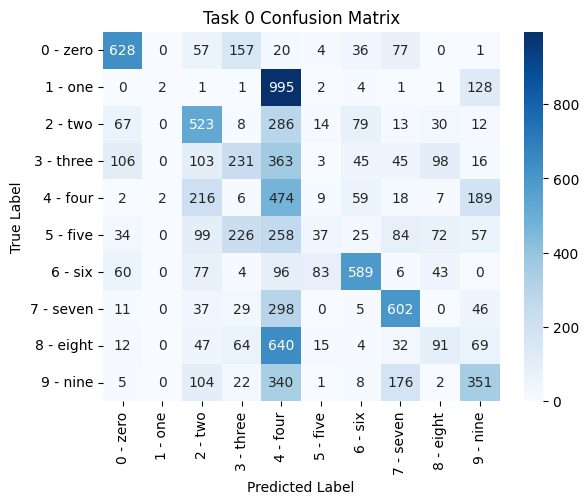

In [13]:
true_label = []
pred_label = []
with torch.no_grad():
    for data in task_1_loader:
        img, label = data
        img, label = img.to(device), label.to(device)
        output = model(img).argmax(1)
        true_label.extend(label.cpu().numpy())
        pred_label.extend(output.cpu().numpy())

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
print('\033[33m' + 'Accuracy' + '\033[0m', accuracy_score(true_label, pred_label))
print('\033[33m' + 'Classification Report' + '\033[0m',
      classification_report(true_label, pred_label, target_names=test_task_1.classes),
      sep='\n')
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_label, pred_label)
plt.cla(); plt.clf()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_task_1.classes, yticklabels=test_task_1.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Task 0 Confusion Matrix")
plt.show()

 - Task 1

Accuracy 0.8509
Classification Report
              precision    recall  f1-score   support

    0 - zero       0.83      0.88      0.85       980
     1 - one       0.94      0.97      0.96      1135
     2 - two       0.77      0.67      0.72      1032
   3 - three       0.85      0.85      0.85      1010
    4 - four       0.86      0.89      0.87       982
    5 - five       0.83      0.79      0.81       892
     6 - six       0.86      0.91      0.89       958
   7 - seven       0.91      0.90      0.91      1028
   8 - eight       0.77      0.78      0.77       974
    9 - nine       0.86      0.86      0.86      1009

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



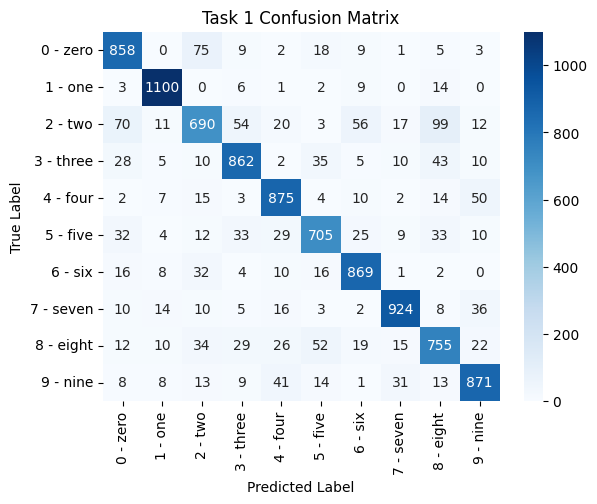

In [14]:
true_label = []
pred_label = []
with torch.no_grad():
    for data in task_2_loader:
        img, label = data
        img, label = img.to(device), label.to(device)
        output = model(img).argmax(1)
        true_label.extend(label.cpu().numpy())
        pred_label.extend(output.cpu().numpy())

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
print('\033[33m' + 'Accuracy' + '\033[0m', accuracy_score(true_label, pred_label))
print('\033[33m' + 'Classification Report' + '\033[0m',
      classification_report(true_label, pred_label, target_names=test_task_2.classes),
      sep='\n')
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true_label, pred_label)
plt.cla(); plt.clf()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=test_task_2.classes, yticklabels=test_task_2.classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Task 1 Confusion Matrix")
plt.show()

net.1.weight
torch.Size([10, 784])
Max fisher is 0.04422 and it's parameter diff is 0.00226
Max Parameter diff is 0.90029 and it's fisher is 0.00000
fisher > parameter diff: 201
fisher <= parameter diff: 583
fisher == 0: 493/784(0.63%)


<Figure size 640x480 with 0 Axes>

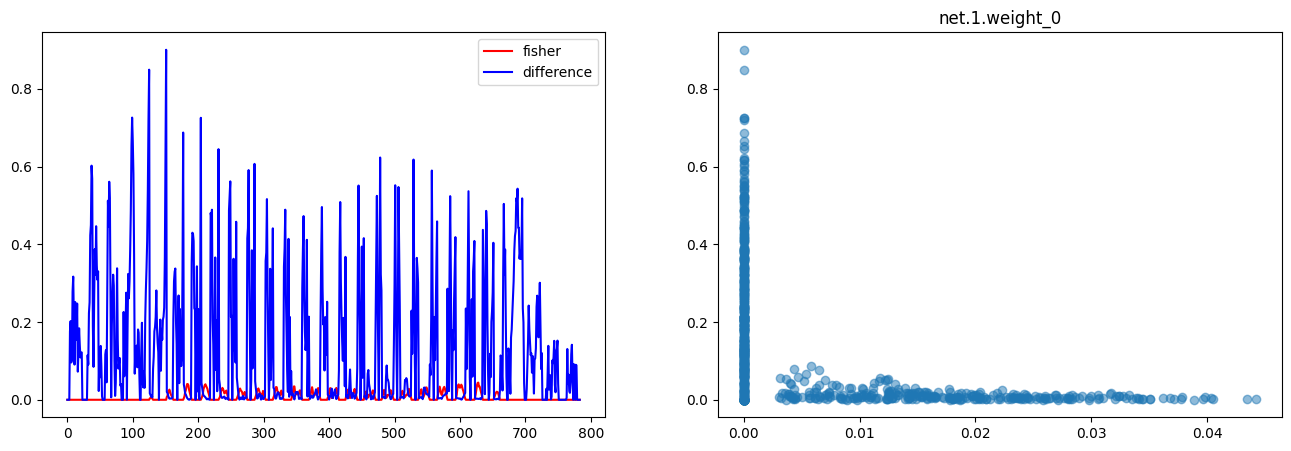

Max fisher is 0.03829 and it's parameter diff is 0.00248
Max Parameter diff is 1.03964 and it's fisher is 0.00000
fisher > parameter diff: 58
fisher <= parameter diff: 726
fisher == 0: 710/784(0.91%)


<Figure size 640x480 with 0 Axes>

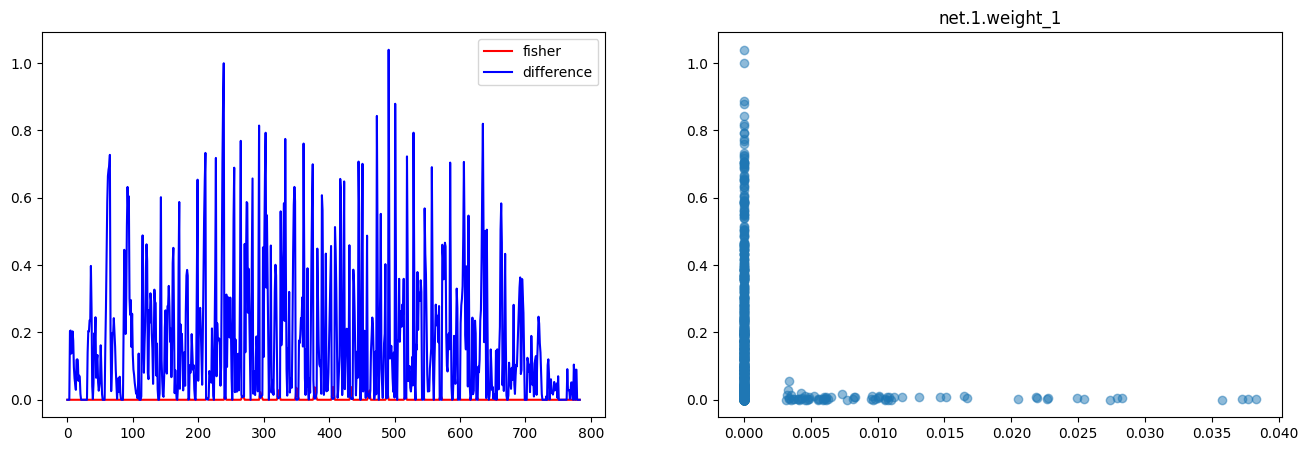

Max fisher is 0.07451 and it's parameter diff is 0.00124
Max Parameter diff is 1.08427 and it's fisher is 0.00000
fisher > parameter diff: 197
fisher <= parameter diff: 587
fisher == 0: 514/784(0.66%)


<Figure size 640x480 with 0 Axes>

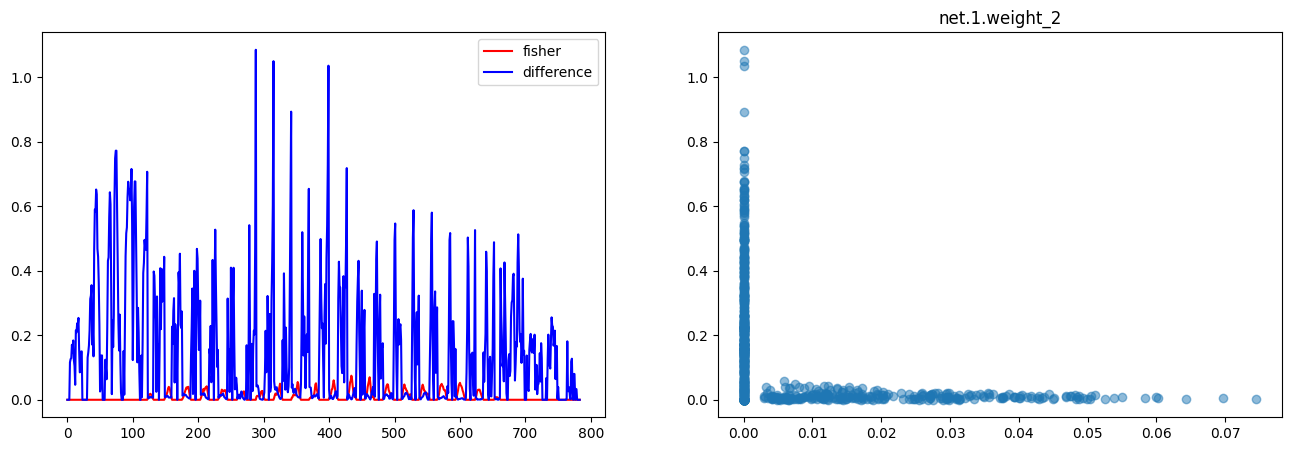

Max fisher is 0.01022 and it's parameter diff is 0.00386
Max Parameter diff is 1.03632 and it's fisher is 0.00000
fisher > parameter diff: 41
fisher <= parameter diff: 743
fisher == 0: 684/784(0.87%)


<Figure size 640x480 with 0 Axes>

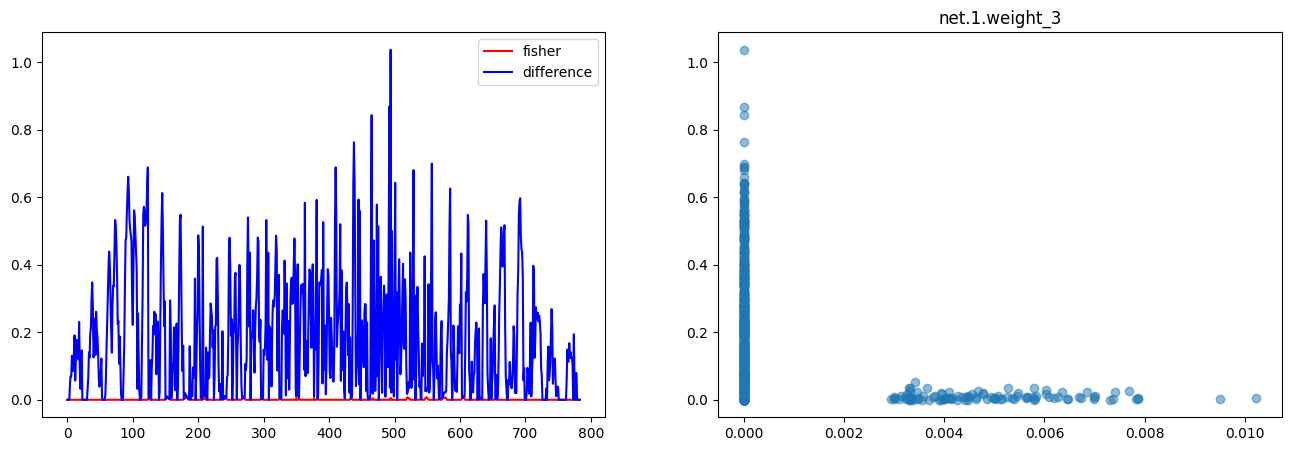

Max fisher is 0.01237 and it's parameter diff is 0.02118
Max Parameter diff is 0.95837 and it's fisher is 0.00000
fisher > parameter diff: 22
fisher <= parameter diff: 762
fisher == 0: 696/784(0.89%)


<Figure size 640x480 with 0 Axes>

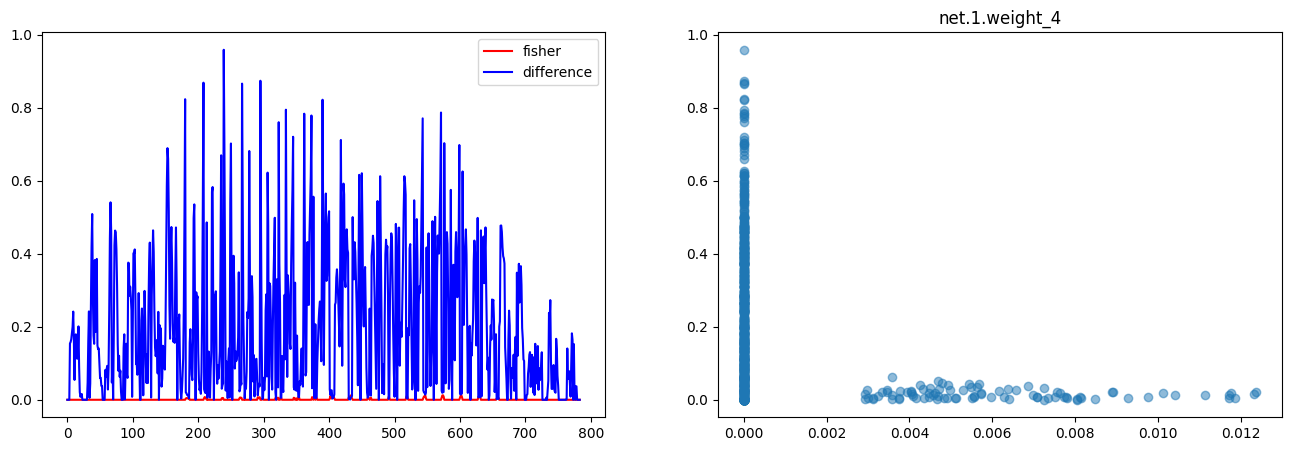

Max fisher is 0.01344 and it's parameter diff is 0.01903
Max Parameter diff is 1.16764 and it's fisher is 0.00000
fisher > parameter diff: 41
fisher <= parameter diff: 743
fisher == 0: 680/784(0.87%)


<Figure size 640x480 with 0 Axes>

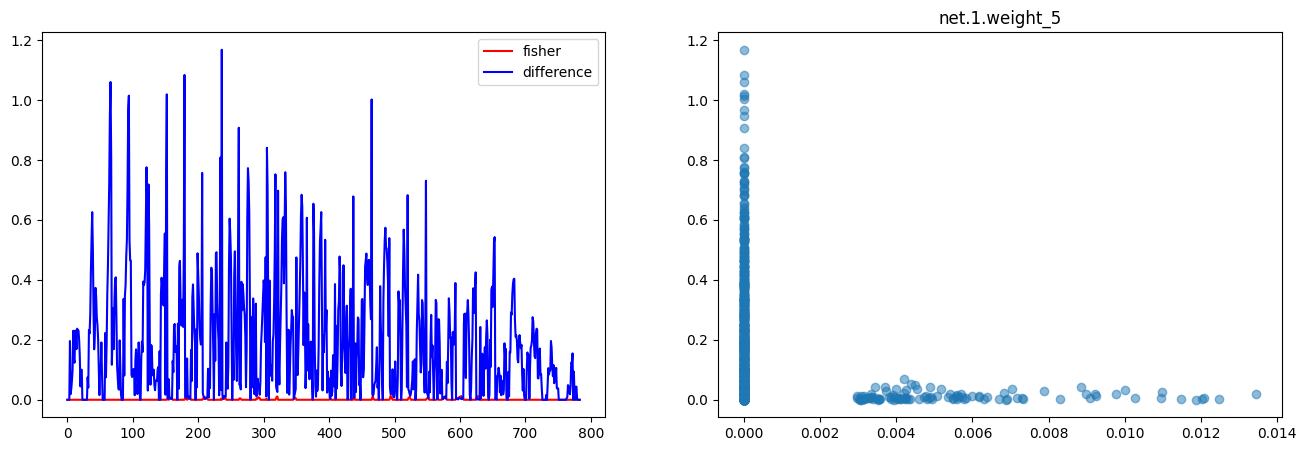

Max fisher is 0.03641 and it's parameter diff is 0.00110
Max Parameter diff is 0.82021 and it's fisher is 0.00000
fisher > parameter diff: 105
fisher <= parameter diff: 679
fisher == 0: 584/784(0.74%)


<Figure size 640x480 with 0 Axes>

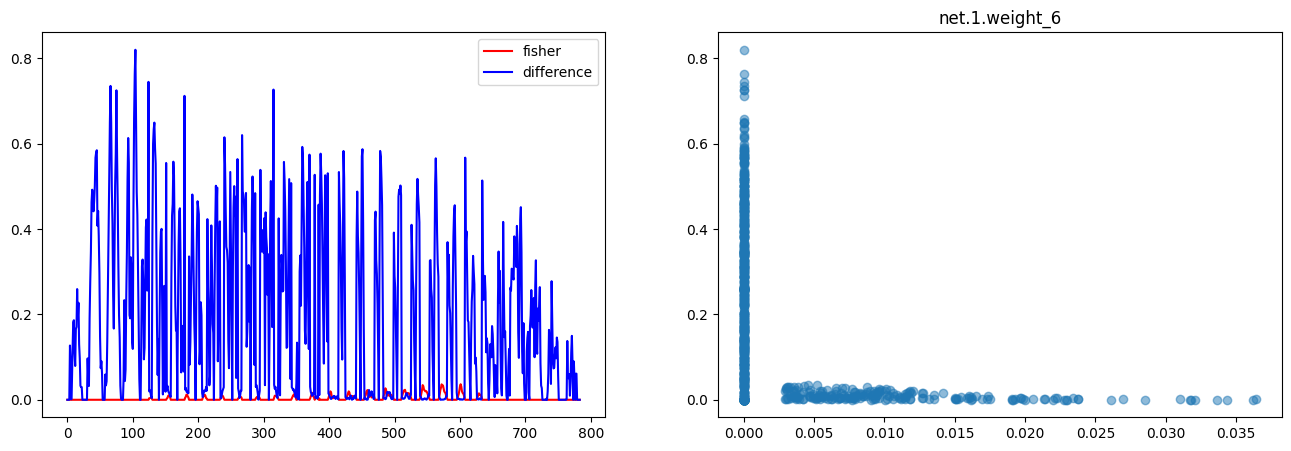

Max fisher is 0.01273 and it's parameter diff is 0.01384
Max Parameter diff is 1.22746 and it's fisher is 0.00000
fisher > parameter diff: 43
fisher <= parameter diff: 741
fisher == 0: 696/784(0.89%)


<Figure size 640x480 with 0 Axes>

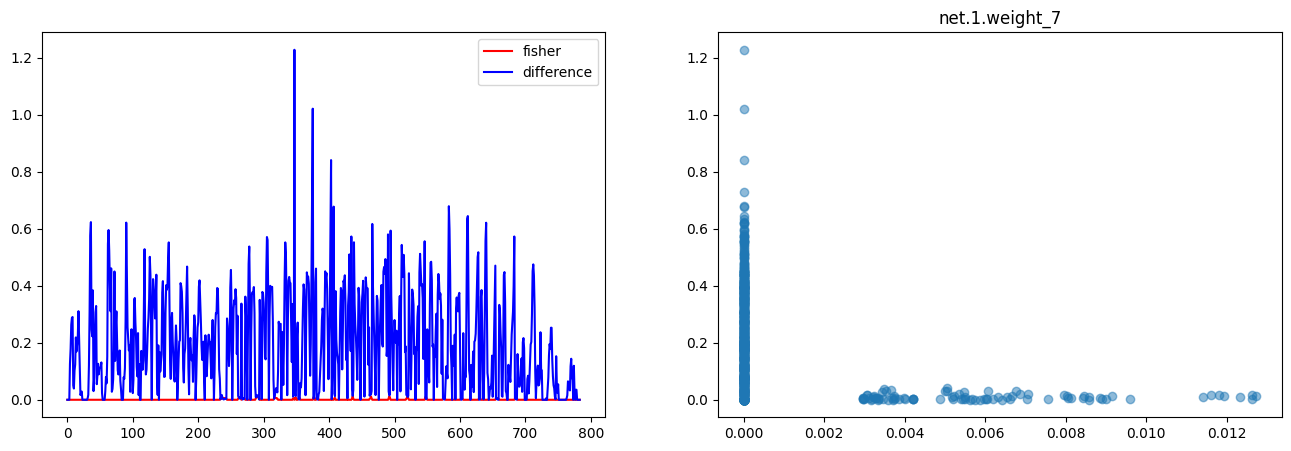

Max fisher is 0.05928 and it's parameter diff is 0.00230
Max Parameter diff is 0.82443 and it's fisher is 0.00000
fisher > parameter diff: 228
fisher <= parameter diff: 556
fisher == 0: 505/784(0.64%)


<Figure size 640x480 with 0 Axes>

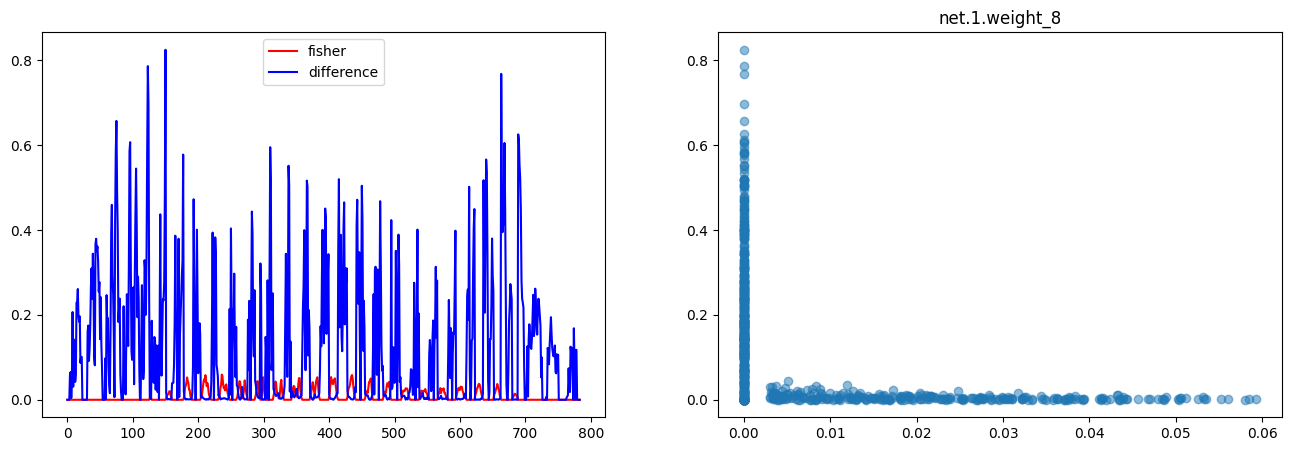

Max fisher is 0.01592 and it's parameter diff is 0.00234
Max Parameter diff is 0.78038 and it's fisher is 0.00000
fisher > parameter diff: 43
fisher <= parameter diff: 741
fisher == 0: 709/784(0.90%)


<Figure size 640x480 with 0 Axes>

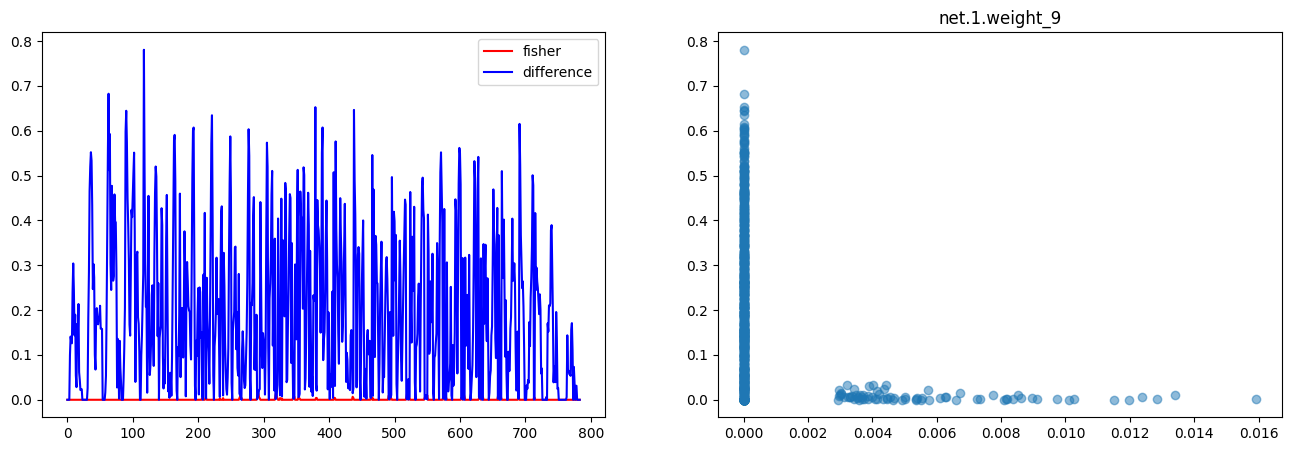


net.1.bias
torch.Size([10])
Max fisher is 0.14252 and it's parameter diff is 0.00001
Max Parameter diff is 1.04592 and it's fisher is 0.00000
fisher > parameter diff: 3
fisher <= parameter diff: 7
fisher == 0: 7/10(0.70%)


<Figure size 640x480 with 0 Axes>

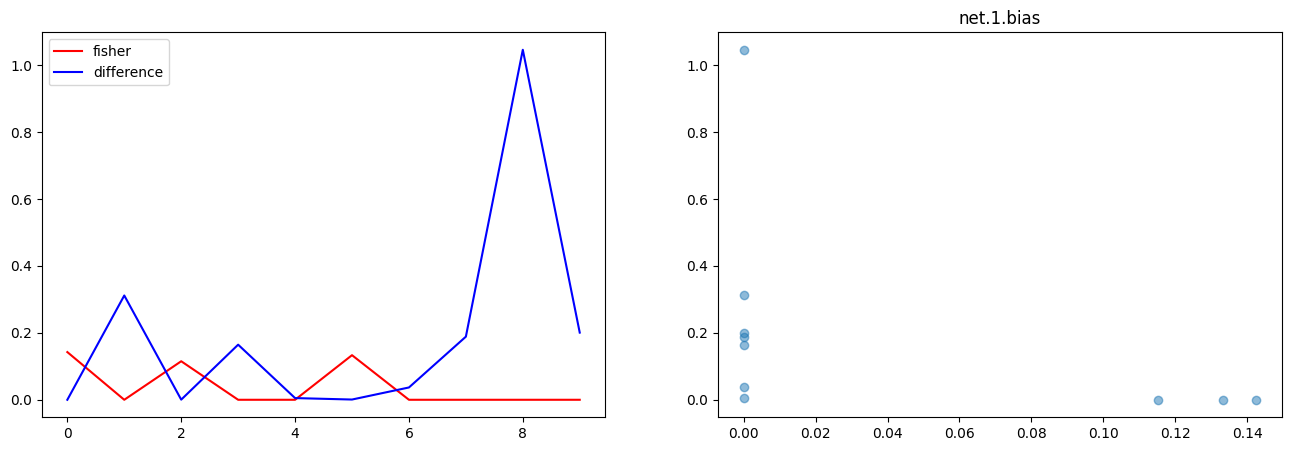

In [15]:
def plot(fisher_matrix, optim_para, param, name):
  plt.cla(); plt.clf()
  #print(fisher_matrix.shape, optim_para.shape, param.shape)
  fisher = fisher_matrix.cpu().detach()
  optim = optim_para.cpu().detach()
  param = param.cpu().detach()

  fisher_max = np.argmax(fisher)
  param_diff_max = np.argmax((optim - param).abs())
  print(f'Max fisher is {fisher[fisher_max]:.5f} and it\'s parameter diff is {(optim - param).abs()[fisher_max]:.5f}')
  print(f'Max Parameter diff is {(optim - param).abs()[param_diff_max]:.5f} and it\'s fisher is {fisher[param_diff_max]:.5f}')
  # compare
  print('fisher > parameter diff: {}'.format((fisher > (optim - param).abs()).sum()))
  print('fisher <= parameter diff: {}'.format((fisher <= (optim - param).abs()).sum()))
  print('fisher == 0: {}/{}({:.2f}%)'.format((fisher == 0).sum(), fisher.shape[0], (fisher == 0).sum() / fisher.shape[0]))

  # plot
  fig, ax = plt.subplots(1, 2, figsize=(16, 5)) # row, col
  ax[0].plot(fisher.reshape(-1), 'r', label='fisher')
  ax[0].plot((optim - param).abs().reshape(-1), 'b', label='difference')
  ax[0].legend()

  ax[1].scatter(fisher, (optim - param).abs().reshape(-1), alpha=0.5)
  plt.title(name)
  plt.show()

# test
idx = 0
for name, param in model.named_parameters():

  # Name
  print(name)
  print(param.detach().shape)

  if len(param.detach().shape) != 1:
    for i in range(param.detach().shape[0]):
      plot(fisher_matrix[0][name][i], optim_para[0][name][i], param[i], f'{name}_{i}')
  else:
    plot(fisher_matrix[0][name], optim_para[0][name], param, name)
  # END
  idx += 1
  print()

In [16]:
import datetime
import pytz

now = datetime.datetime.now(pytz.timezone('Asia/Taipei')).strftime("%Y-%m-%d_%H_%M_%S")
print(now)

2025-03-31_21_32_31
